<a href="https://colab.research.google.com/github/tini030205-debug/Deep-Learning-1Team/blob/main/food_classification_resnet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Colab 한글 폰트 설치
!apt-get update -qq
!apt-get install -y fonts-nanum -qq

print("나눔 폰트 설치 완료")

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
나눔 폰트 설치 완료


In [2]:
# 기본 라이브러리
import os
import random
import zipfile
from pathlib import Path

# 데이터 확인 및 시각화
import matplotlib.pyplot as plt
from PIL import Image

# 딥러닝 관련 라이브러리
import numpy as np
import torch

In [3]:
# Google Drive 마운트
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Random Seed 고정
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# GPU 사용 시에도 seed 고정
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

# 재현성 향상을 위한 설정
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Random Seed 고정 완료: {SEED}")

Random Seed 고정 완료: 42


In [5]:
# GPU 사용 가능 여부 확인
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("현재 사용 장치:", device)

if torch.cuda.is_available():
    print("GPU 이름:", torch.cuda.get_device_name(0))
else:
    print("GPU를 사용할 수 없습니다. Colab 런타임 유형에서 GPU를 선택하세요.")

현재 사용 장치: cuda
GPU 이름: Tesla T4


In [6]:
# zip 파일 경로 설정
zip_path = "/content/drive/MyDrive/딥러닝 데이터(300).zip"

# 압축 해제할 경로 설정
extract_dir = "/content/deep_learning_data"

# 압축 해제 경로 생성
os.makedirs(extract_dir, exist_ok=True)

# zip 파일 압축 해제
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("압축 해제 완료")
print("압축 해제 위치:", extract_dir)

압축 해제 완료
압축 해제 위치: /content/deep_learning_data


In [7]:
# 압축 해제 후 최상위 폴더 확인
print("압축 해제 폴더 내부 목록:")
for item in os.listdir(extract_dir):
    print("-", item)

압축 해제 폴더 내부 목록:
- 딥러닝 데이터(300)


In [8]:
# 압축 해제된 실제 데이터 폴더 경로 설정
data_root = os.path.join(extract_dir, "딥러닝 데이터(300)")

# Train / Validation / Test 경로 설정
train_dir = os.path.join(data_root, "Train")
valid_dir = os.path.join(data_root, "Validation")
test_dir = os.path.join(data_root, "Test")

# 경로 확인
print("데이터 루트 경로:", data_root)
print("Train 경로:", train_dir)
print("Validation 경로:", valid_dir)
print("Test 경로:", test_dir)

# 폴더 존재 여부 확인
print("\n폴더 존재 여부 확인")
print("Train 존재:", os.path.exists(train_dir))
print("Validation 존재:", os.path.exists(valid_dir))
print("Test 존재:", os.path.exists(test_dir))

데이터 루트 경로: /content/deep_learning_data/딥러닝 데이터(300)
Train 경로: /content/deep_learning_data/딥러닝 데이터(300)/Train
Validation 경로: /content/deep_learning_data/딥러닝 데이터(300)/Validation
Test 경로: /content/deep_learning_data/딥러닝 데이터(300)/Test

폴더 존재 여부 확인
Train 존재: True
Validation 존재: True
Test 존재: True


In [9]:
# Train 폴더 안의 하위 폴더명을 기준으로 클래스 자동 인식
class_names = sorted([
    folder for folder in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, folder))
])

print("자동 인식된 클래스 이름:")
for idx, class_name in enumerate(class_names):
    print(f"{idx}: {class_name}")

자동 인식된 클래스 이름:
0: 계란후라이
1: 고사리나물
2: 더덕구이
3: 동그랑땡
4: 두부조림
5: 땅콩조림
6: 미역줄기 볶음
7: 생선전
8: 연근 조림
9: 파전


In [10]:
# 클래스 개수 출력
num_classes = len(class_names)

print("클래스 개수:", num_classes)

클래스 개수: 10


In [11]:
# 이미지 확장자 목록
image_extensions = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

# 클래스별 이미지 수를 세는 함수
def count_images_by_class(base_dir, class_names):
    class_counts = {}

    for class_name in class_names:
        class_dir = os.path.join(base_dir, class_name)

        image_count = len([
            file for file in os.listdir(class_dir)
            if os.path.isfile(os.path.join(class_dir, file))
            and Path(file).suffix.lower() in image_extensions
        ])

        class_counts[class_name] = image_count

    return class_counts

# Train / Validation / Test 각각 클래스별 이미지 수 확인
train_counts = count_images_by_class(train_dir, class_names)
valid_counts = count_images_by_class(valid_dir, class_names)
test_counts = count_images_by_class(test_dir, class_names)

print("[Train 클래스별 이미지 수]")
for class_name, count in train_counts.items():
    print(f"{class_name}: {count}장")

print("\n[Validation 클래스별 이미지 수]")
for class_name, count in valid_counts.items():
    print(f"{class_name}: {count}장")

print("\n[Test 클래스별 이미지 수]")
for class_name, count in test_counts.items():
    print(f"{class_name}: {count}장")

[Train 클래스별 이미지 수]
계란후라이: 240장
고사리나물: 240장
더덕구이: 240장
동그랑땡: 240장
두부조림: 240장
땅콩조림: 240장
미역줄기 볶음: 240장
생선전: 240장
연근 조림: 240장
파전: 240장

[Validation 클래스별 이미지 수]
계란후라이: 30장
고사리나물: 30장
더덕구이: 30장
동그랑땡: 30장
두부조림: 30장
땅콩조림: 30장
미역줄기 볶음: 30장
생선전: 30장
연근 조림: 30장
파전: 30장

[Test 클래스별 이미지 수]
계란후라이: 30장
고사리나물: 30장
더덕구이: 30장
동그랑땡: 30장
두부조림: 30장
땅콩조림: 30장
미역줄기 볶음: 30장
생선전: 30장
연근 조림: 30장
파전: 30장


In [12]:
# 전체 이미지 수 계산
total_train = sum(train_counts.values())
total_valid = sum(valid_counts.values())
total_test = sum(test_counts.values())
total_images = total_train + total_valid + total_test

print("Train 전체 이미지 수:", total_train)
print("Validation 전체 이미지 수:", total_valid)
print("Test 전체 이미지 수:", total_test)
print("전체 이미지 수:", total_images)

Train 전체 이미지 수: 2400
Validation 전체 이미지 수: 300
Test 전체 이미지 수: 300
전체 이미지 수: 3000


/tmp/ipykernel_6188/2627532553.py:27: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6188/2627532553.py:27: UserWarning: Glyph 46976 (\N{HANGUL SYLLABLE RAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6188/2627532553.py:27: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6188/2627532553.py:27: UserWarning: Glyph 46972 (\N{HANGUL SYLLABLE RA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6188/2627532553.py:27: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6188/2627532553.py:27: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6188/2627532553.py:27: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout(

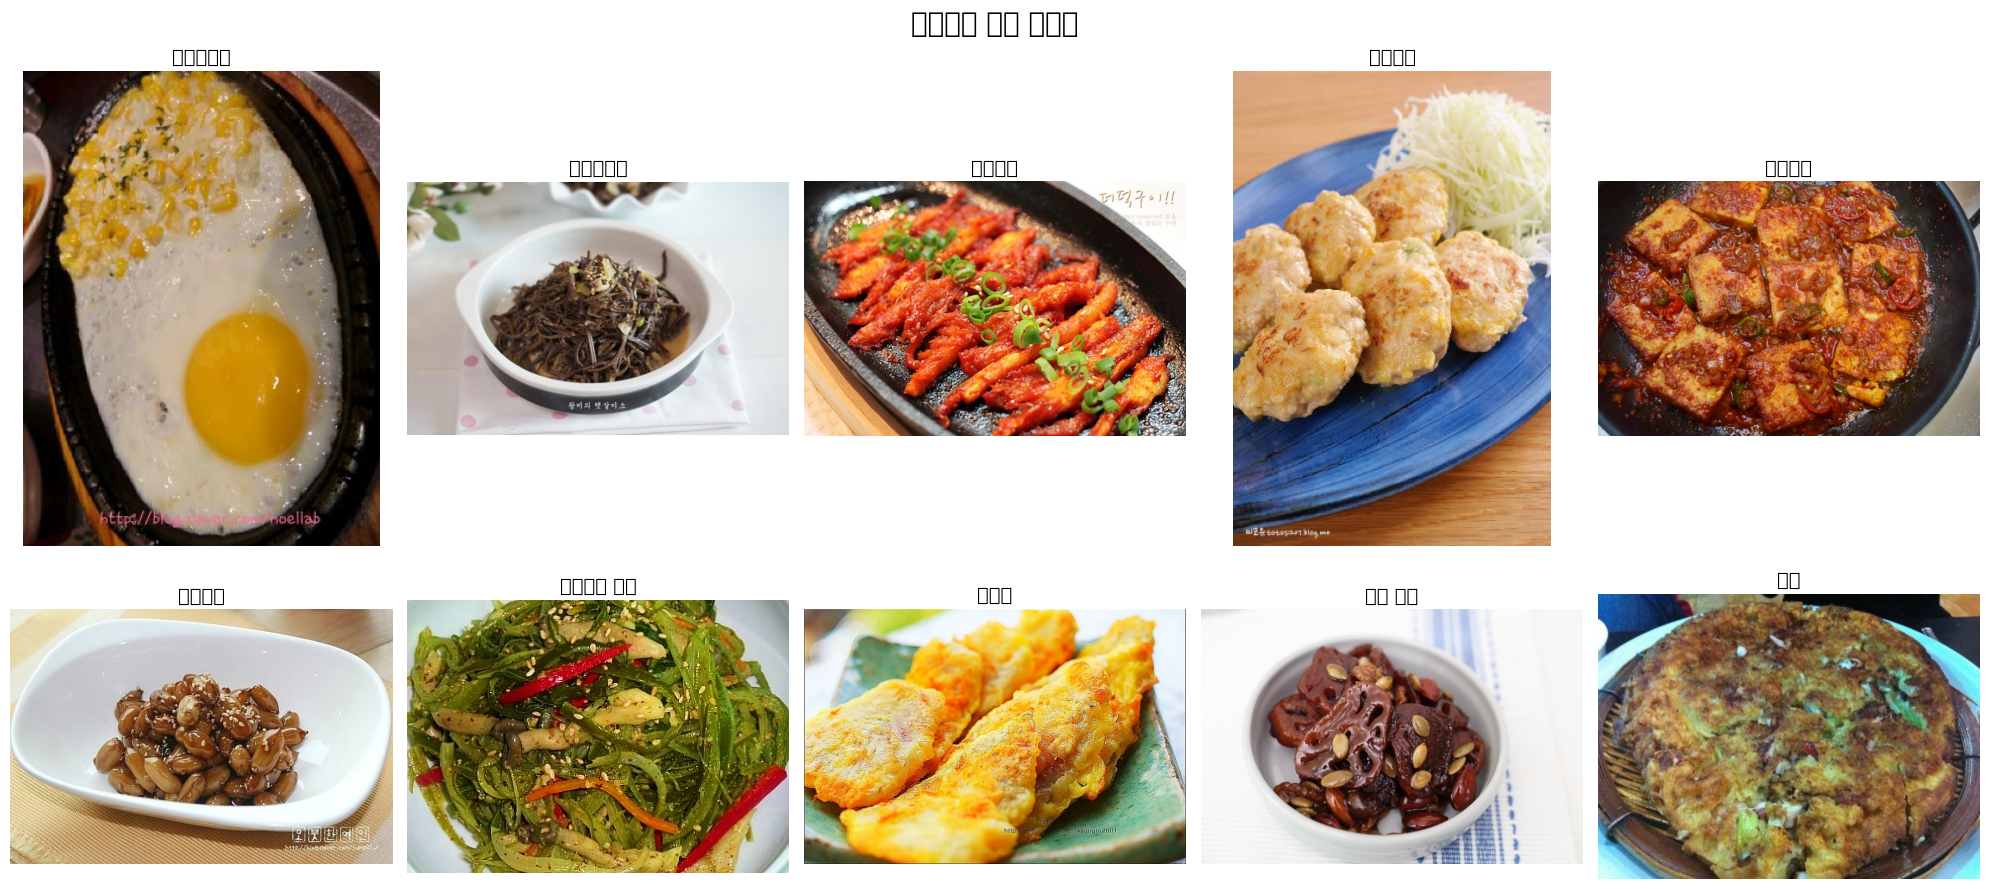

In [13]:
# 클래스별 샘플 이미지 시각화
plt.figure(figsize=(20, 10))

for idx, class_name in enumerate(class_names):
    class_dir = os.path.join(train_dir, class_name)

    image_files = [
        file for file in os.listdir(class_dir)
        if os.path.isfile(os.path.join(class_dir, file))
        and Path(file).suffix.lower() in image_extensions
    ]

    # 클래스별 이미지 중 하나를 랜덤 선택
    sample_image_name = random.choice(image_files)
    sample_image_path = os.path.join(class_dir, sample_image_name)

    # 이미지 열기
    image = Image.open(sample_image_path).convert("RGB")

    # 시각화
    plt.subplot(2, 5, idx + 1)
    plt.imshow(image)
    plt.title(class_name, fontsize=14)
    plt.axis("off")

plt.suptitle("클래스별 샘플 이미지", fontsize=20)
plt.tight_layout()
plt.show()

In [14]:
# PyTorch 데이터셋 및 데이터로더 관련 라이브러리
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# 경로 확인용
import os

In [15]:
# 입력 이미지 크기 설정
IMG_SIZE = 224

# 배치 크기 설정
BATCH_SIZE = 32

# GPU 사용 여부에 따른 device 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("입력 이미지 크기:", IMG_SIZE)
print("배치 크기:", BATCH_SIZE)
print("사용 장치:", device)

입력 이미지 크기: 224
배치 크기: 32
사용 장치: cuda


In [16]:
# ImageNet 사전학습 모델에서 일반적으로 사용하는 Normalize 값
# 추후 전이학습 모델을 사용할 때도 동일하게 사용할 수 있음
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

In [17]:
# Train 데이터 Transform
# Train 데이터에는 데이터 증강을 적용함
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),          # 이미지를 224x224 크기로 변경
    transforms.RandomHorizontalFlip(p=0.5),           # 50% 확률로 좌우 반전
    transforms.RandomRotation(degrees=15),            # -15도 ~ +15도 범위에서 회전
    transforms.ColorJitter(                           # 밝기, 대비, 채도, 색조 변화
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),                            # 이미지를 Tensor 형태로 변환
    transforms.Normalize(                             # ImageNet 기준 정규화
        mean=imagenet_mean,
        std=imagenet_std
    )
])

# Validation / Test 데이터 Transform
# 검증과 테스트 데이터에는 증강을 적용하지 않음
valid_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),          # 이미지를 224x224 크기로 변경
    transforms.ToTensor(),                            # 이미지를 Tensor 형태로 변환
    transforms.Normalize(                             # ImageNet 기준 정규화
        mean=imagenet_mean,
        std=imagenet_std
    )
])

In [18]:
# 1단계에서 설정한 경로가 정상인지 확인
print("Train 경로:", train_dir)
print("Validation 경로:", valid_dir)
print("Test 경로:", test_dir)

print("\n경로 존재 여부")
print("Train:", os.path.exists(train_dir))
print("Validation:", os.path.exists(valid_dir))
print("Test:", os.path.exists(test_dir))

Train 경로: /content/deep_learning_data/딥러닝 데이터(300)/Train
Validation 경로: /content/deep_learning_data/딥러닝 데이터(300)/Validation
Test 경로: /content/deep_learning_data/딥러닝 데이터(300)/Test

경로 존재 여부
Train: True
Validation: True
Test: True


In [19]:
# ImageFolder는 폴더명을 클래스 이름으로 자동 인식함
# 한글 클래스명과 공백이 포함된 폴더명도 정상 처리 가능함
train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=train_transform
)

valid_dataset = datasets.ImageFolder(
    root=valid_dir,
    transform=valid_test_transform
)

test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=valid_test_transform
)

print("ImageFolder Dataset 생성 완료")

ImageFolder Dataset 생성 완료


In [20]:
# ImageFolder가 인식한 클래스 이름 확인
# folder 이름 기준으로 자동 정렬되어 라벨 번호가 부여됨
print("Train Dataset 클래스 목록:")
print(train_dataset.classes)

print("\n클래스 개수:", len(train_dataset.classes))

print("\n클래스명 → 라벨 인덱스 매핑:")
for class_name, label_idx in train_dataset.class_to_idx.items():
    print(f"{class_name}: {label_idx}")

Train Dataset 클래스 목록:
['계란후라이', '고사리나물', '더덕구이', '동그랑땡', '두부조림', '땅콩조림', '미역줄기 볶음', '생선전', '연근 조림', '파전']

클래스 개수: 10

클래스명 → 라벨 인덱스 매핑:
계란후라이: 0
고사리나물: 1
더덕구이: 2
동그랑땡: 3
두부조림: 4
땅콩조림: 5
미역줄기 볶음: 6
생선전: 7
연근 조림: 8
파전: 9


In [21]:
# Train / Validation / Test의 클래스 순서가 같은지 확인
print("Train 클래스:", train_dataset.classes)
print("Validation 클래스:", valid_dataset.classes)
print("Test 클래스:", test_dataset.classes)

print("\n클래스 목록 일치 여부")
print("Train == Validation:", train_dataset.classes == valid_dataset.classes)
print("Train == Test:", train_dataset.classes == test_dataset.classes)

Train 클래스: ['계란후라이', '고사리나물', '더덕구이', '동그랑땡', '두부조림', '땅콩조림', '미역줄기 볶음', '생선전', '연근 조림', '파전']
Validation 클래스: ['계란후라이', '고사리나물', '더덕구이', '동그랑땡', '두부조림', '땅콩조림', '미역줄기 볶음', '생선전', '연근 조림', '파전']
Test 클래스: ['계란후라이', '고사리나물', '더덕구이', '동그랑땡', '두부조림', '땅콩조림', '미역줄기 볶음', '생선전', '연근 조림', '파전']

클래스 목록 일치 여부
Train == Validation: True
Train == Test: True


In [22]:
# 각 Dataset에 포함된 전체 이미지 수 확인
print("Train Dataset 이미지 수:", len(train_dataset))
print("Validation Dataset 이미지 수:", len(valid_dataset))
print("Test Dataset 이미지 수:", len(test_dataset))

print("\n전체 이미지 수:", len(train_dataset) + len(valid_dataset) + len(test_dataset))

Train Dataset 이미지 수: 2400
Validation Dataset 이미지 수: 300
Test Dataset 이미지 수: 300

전체 이미지 수: 3000


In [23]:
# Colab 환경에서 일반적으로 사용 가능한 num_workers 설정
# 오류가 발생하면 num_workers=0으로 바꾸면 됨
NUM_WORKERS = 2

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,              # Train은 데이터 순서를 섞음
    num_workers=NUM_WORKERS,
    pin_memory=True
)

valid_loader = DataLoader(
    dataset=valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,             # Validation은 데이터 순서를 섞지 않음
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,             # Test는 데이터 순서를 섞지 않음
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("DataLoader 생성 완료")

DataLoader 생성 완료


In [24]:
# Train DataLoader에서 배치 하나 꺼내기
images, labels = next(iter(train_loader))

print("이미지 batch shape:", images.shape)
print("라벨 batch shape:", labels.shape)

print("\n이미지 Tensor 자료형:", images.dtype)
print("라벨 Tensor 자료형:", labels.dtype)

print("\n이미지 batch 최소값:", images.min().item())
print("이미지 batch 최대값:", images.max().item())

print("\n라벨 예시:", labels[:10])

이미지 batch shape: torch.Size([32, 3, 224, 224])
라벨 batch shape: torch.Size([32])

이미지 Tensor 자료형: torch.float32
라벨 Tensor 자료형: torch.int64

이미지 batch 최소값: -2.1179039478302
이미지 batch 최대값: 2.640000104904175

라벨 예시: tensor([7, 5, 2, 7, 0, 0, 8, 5, 8, 1])


In [25]:
# Validation DataLoader에서 배치 하나 확인
valid_images, valid_labels = next(iter(valid_loader))

print("[Validation Batch]")
print("이미지 shape:", valid_images.shape)
print("라벨 shape:", valid_labels.shape)

# Test DataLoader에서 배치 하나 확인
test_images, test_labels = next(iter(test_loader))

print("\n[Test Batch]")
print("이미지 shape:", test_images.shape)
print("라벨 shape:", test_labels.shape)

[Validation Batch]
이미지 shape: torch.Size([32, 3, 224, 224])
라벨 shape: torch.Size([32])

[Test Batch]
이미지 shape: torch.Size([32, 3, 224, 224])
라벨 shape: torch.Size([32])


In [26]:
# =========================
# 3단계-1. 라이브러리 import
# =========================

import os
import random
import time
import copy

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models
from torch.optim.lr_scheduler import CosineAnnealingLR

In [27]:
# =========================
# 3단계-2. Random Seed 고정
# =========================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Random Seed 고정 완료:", SEED)

Random Seed 고정 완료: 42


In [28]:
# =========================
# 3단계-3. Scratch ResNet50 모델 정의
# =========================

# 클래스 개수 확인
NUM_CLASSES = 10

# ImageNet 사전학습 가중치를 사용하지 않는 ResNet50 생성
# weights=None 이므로 Scratch 모델임
scratch_model = models.resnet50(weights=None)

# 기존 ResNet50의 마지막 FC Layer 입력 feature 수 확인
in_features = scratch_model.fc.in_features

# 마지막 FC Layer를 10개 클래스 출력으로 변경
scratch_model.fc = nn.Linear(in_features, NUM_CLASSES)

# 모델을 GPU 또는 CPU로 이동
scratch_model = scratch_model.to(device)

print("Scratch ResNet50 모델 생성 완료")
print("마지막 FC Layer:", scratch_model.fc)
print("출력 클래스 수:", NUM_CLASSES)
print("사용 장치:", device)

Scratch ResNet50 모델 생성 완료
마지막 FC Layer: Linear(in_features=2048, out_features=10, bias=True)
출력 클래스 수: 10
사용 장치: cuda


In [29]:
# =========================
# 3단계-4. Loss / Optimizer / Scheduler 정의
# =========================

# Loss Function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(
    scratch_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

# Scheduler
scheduler = CosineAnnealingLR(
    optimizer,
    T_max=100
)

print("Loss Function:", criterion)
print("Optimizer:", optimizer)
print("Scheduler:", scheduler)

Loss Function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.001
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
Scheduler: <torch.optim.lr_scheduler.CosineAnnealingLR object at 0x7ea8b7f01340>


In [30]:
# =========================
# 3단계-5. EarlyStopping 클래스 정의
# =========================

class EarlyStopping:
    """
    Validation Loss를 기준으로 Early Stopping을 수행하는 클래스
    patience 동안 val_loss가 개선되지 않으면 학습을 중단함
    """

    def __init__(self, patience=10, min_delta=0.0):
        """
        patience: 개선이 없어도 기다릴 epoch 수
        min_delta: 개선으로 인정할 최소 감소량
        """
        self.patience = patience
        self.min_delta = min_delta

        self.best_loss = np.inf
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss):
        """
        현재 epoch의 validation loss를 입력받아 early stopping 여부 판단
        """

        # val_loss가 best_loss보다 충분히 감소한 경우
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0

        # 개선되지 않은 경우
        else:
            self.counter += 1
            print(f"EarlyStopping Counter: {self.counter}/{self.patience}")

            if self.counter >= self.patience:
                self.early_stop = True

In [31]:
# =========================
# 3단계-6. 정확도 계산 함수 정의
# =========================

def calculate_accuracy(outputs, labels):
    """
    모델 출력값과 실제 라벨을 이용해 accuracy 계산
    """

    # outputs에서 가장 큰 값을 가진 클래스 index 선택
    _, preds = torch.max(outputs, dim=1)

    # 맞춘 개수 계산
    correct = torch.sum(preds == labels).item()

    return correct

In [32]:
# =========================
# 3단계-7. train_model 함수 정의
# =========================

def train_model(
    model,
    train_loader,
    valid_loader,
    criterion,
    optimizer,
    scheduler,
    num_epochs=100,
    patience=10,
    save_path="scratch_best_model.pth",
    history_path="scratch_history.csv"
):
    """
    ResNet50 Scratch 모델 학습 함수

    저장 기준:
    - best model: validation loss가 가장 낮을 때 저장
    - history: epoch별 train_loss, val_loss, train_acc, val_acc, learning_rate 저장
    """

    since = time.time()

    # EarlyStopping 객체 생성
    early_stopping = EarlyStopping(patience=patience)

    # best val_loss 초기화
    best_val_loss = np.inf

    # best model weight 저장용
    best_model_wts = copy.deepcopy(model.state_dict())

    # 학습 기록 저장 리스트
    history = []

    print("학습 시작")
    print("=" * 80)

    for epoch in range(num_epochs):
        print(f"\nEpoch [{epoch + 1}/{num_epochs}]")
        print("-" * 80)

        # =========================
        # Train 단계
        # =========================
        model.train()

        train_loss_sum = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            # 데이터를 device로 이동
            images = images.to(device)
            labels = labels.to(device)

            # 이전 gradient 초기화
            optimizer.zero_grad()

            # Forward
            outputs = model(images)

            # Loss 계산
            loss = criterion(outputs, labels)

            # Backward
            loss.backward()

            # Optimizer update
            optimizer.step()

            # 통계 누적
            batch_size = images.size(0)
            train_loss_sum += loss.item() * batch_size
            train_correct += calculate_accuracy(outputs, labels)
            train_total += batch_size

        # epoch 단위 train loss / accuracy 계산
        train_loss = train_loss_sum / train_total
        train_acc = train_correct / train_total

        # =========================
        # Validation 단계
        # =========================
        model.eval()

        val_loss_sum = 0.0
        val_correct = 0
        val_total = 0

        # validation에서는 gradient 계산 비활성화
        with torch.no_grad():
            for images, labels in valid_loader:
                images = images.to(device)
                labels = labels.to(device)

                # Forward
                outputs = model(images)

                # Loss 계산
                loss = criterion(outputs, labels)

                # 통계 누적
                batch_size = images.size(0)
                val_loss_sum += loss.item() * batch_size
                val_correct += calculate_accuracy(outputs, labels)
                val_total += batch_size

        # epoch 단위 validation loss / accuracy 계산
        val_loss = val_loss_sum / val_total
        val_acc = val_correct / val_total

        # 현재 learning rate 확인
        current_lr = optimizer.param_groups[0]["lr"]

        # Scheduler update
        scheduler.step()

        # history 저장
        history.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_acc": train_acc,
            "val_acc": val_acc,
            "learning_rate": current_lr
        })

        # epoch 결과 출력
        print(
            f"train_loss: {train_loss:.4f} | "
            f"val_loss: {val_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"val_acc: {val_acc:.4f} | "
            f"learning_rate: {current_lr:.8f}"
        )

        # =========================
        # Best Model 저장 기준: val_loss
        # =========================
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())

            torch.save(model.state_dict(), save_path)

            print(f"Best model 저장 완료: {save_path}")
            print(f"Best val_loss: {best_val_loss:.4f}")

        # =========================
        # EarlyStopping 검사
        # monitor = val_loss
        # =========================
        early_stopping(val_loss)

        if early_stopping.early_stop:
            print("\nEarlyStopping 발생")
            print(f"{patience} epoch 동안 val_loss 개선이 없어 학습을 중단합니다.")
            break

    # 전체 학습 시간 계산
    time_elapsed = time.time() - since

    print("\n" + "=" * 80)
    print("학습 종료")
    print(f"총 학습 시간: {time_elapsed // 60:.0f}분 {time_elapsed % 60:.0f}초")
    print(f"최고 val_loss: {best_val_loss:.4f}")

    # best model weight 로드
    model.load_state_dict(best_model_wts)

    # history를 CSV로 저장
    history_df = pd.DataFrame(history)
    history_df.to_csv(history_path, index=False, encoding="utf-8-sig")

    print(f"학습 기록 저장 완료: {history_path}")
    print(f"Best model 저장 파일: {save_path}")

    return model, history_df

In [33]:
# =========================
# 3단계-8. Scratch ResNet50 학습 실행
# =========================

EPOCHS = 100
PATIENCE = 10

scratch_model, scratch_history = train_model(
    model=scratch_model,
    train_loader=train_loader,
    valid_loader=valid_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=EPOCHS,
    patience=PATIENCE,
    save_path="scratch_best_model.pth",
    history_path="scratch_history.csv"
)

학습 시작

Epoch [1/100]
--------------------------------------------------------------------------------
train_loss: 2.1636 | val_loss: 1.8808 | train_acc: 0.2917 | val_acc: 0.3600 | learning_rate: 0.00100000
Best model 저장 완료: scratch_best_model.pth
Best val_loss: 1.8808

Epoch [2/100]
--------------------------------------------------------------------------------
train_loss: 1.6826 | val_loss: 1.3475 | train_acc: 0.4133 | val_acc: 0.5167 | learning_rate: 0.00099975
Best model 저장 완료: scratch_best_model.pth
Best val_loss: 1.3475

Epoch [3/100]
--------------------------------------------------------------------------------
train_loss: 1.4749 | val_loss: 1.3315 | train_acc: 0.4763 | val_acc: 0.4900 | learning_rate: 0.00099901
Best model 저장 완료: scratch_best_model.pth
Best val_loss: 1.3315

Epoch [4/100]
--------------------------------------------------------------------------------
train_loss: 1.3973 | val_loss: 1.2037 | train_acc: 0.4954 | val_acc: 0.5367 | learning_rate: 0.00099778
Best 

In [34]:
# =========================
# 3단계-9. 저장 파일 확인
# =========================

print("scratch_best_model.pth 존재 여부:", os.path.exists("scratch_best_model.pth"))
print("scratch_history.csv 존재 여부:", os.path.exists("scratch_history.csv"))

scratch_best_model.pth 존재 여부: True
scratch_history.csv 존재 여부: True


In [35]:
# =========================
# 3단계-10. 학습 기록 확인
# =========================

scratch_history.head()
scratch_history.tail()

,epoch,train_loss,val_loss,train_acc,val_acc,learning_rate
84,85,0.027461,0.268433,0.992500,0.910000,0.000062
85,86,0.020515,0.284871,0.994167,0.906667,0.000054
86,87,0.024212,0.279480,0.992917,0.920000,0.000048
87,88,0.038369,0.290763,0.990000,0.910000,0.000041
88,89,0.025380,0.283954,0.994167,0.913333,0.000035


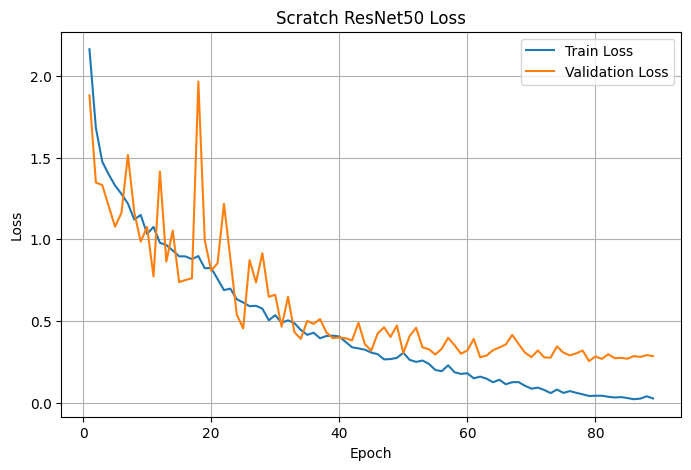

In [36]:
# =========================
# 3단계-11. Loss 그래프 시각화
# =========================

plt.figure(figsize=(8, 5))
plt.plot(scratch_history["epoch"], scratch_history["train_loss"], label="Train Loss")
plt.plot(scratch_history["epoch"], scratch_history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Scratch ResNet50 Loss")
plt.legend()
plt.grid(True)
plt.show()

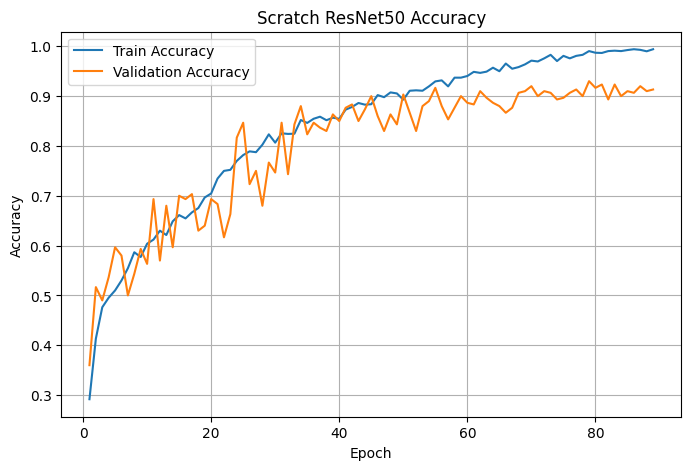

In [37]:
# =========================
# 3단계-12. Accuracy 그래프 시각화
# =========================

plt.figure(figsize=(8, 5))
plt.plot(scratch_history["epoch"], scratch_history["train_acc"], label="Train Accuracy")
plt.plot(scratch_history["epoch"], scratch_history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Scratch ResNet50 Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [38]:
# =========================
# 4단계-1. 라이브러리 import
# =========================

import os
import time
import copy
import random

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import models
from torch.optim.lr_scheduler import CosineAnnealingLR

In [39]:
# =========================
# 4단계-2. Random Seed 고정
# =========================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Random Seed 고정 완료:", SEED)

Random Seed 고정 완료: 42


In [40]:
# =========================
# 4단계-3. ImageNet 사전학습 ResNet50 모델 정의
# =========================

NUM_CLASSES = 10

# torchvision 최신 weights 방식 사용
weights = models.ResNet50_Weights.DEFAULT

# ImageNet 사전학습 ResNet50 로드
transfer_model = models.resnet50(weights=weights)

# 기존 FC Layer 입력 feature 수 확인
in_features = transfer_model.fc.in_features

# 마지막 FC Layer를 10개 클래스 출력으로 변경
# FC Layer 앞에 Dropout(p=0.5) 적용
transfer_model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(in_features, NUM_CLASSES)
)

# 모델을 GPU 또는 CPU로 이동
transfer_model = transfer_model.to(device)

print("Transfer Learning ResNet50 모델 생성 완료")
print("사용 weights:", weights)
print("마지막 FC Layer:")
print(transfer_model.fc)
print("출력 클래스 수:", NUM_CLASSES)
print("사용 장치:", device)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 178MB/s]


Transfer Learning ResNet50 모델 생성 완료
사용 weights: ResNet50_Weights.IMAGENET1K_V2
마지막 FC Layer:
Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=2048, out_features=10, bias=True)
)
출력 클래스 수: 10
사용 장치: cuda


In [41]:
# =========================
# 4단계-4. Feature Extraction 단계 설정
# backbone freeze, FC Layer만 학습
# =========================

# 전체 파라미터 freeze
for param in transfer_model.parameters():
    param.requires_grad = False

# 마지막 FC Layer만 학습 가능하도록 설정
for param in transfer_model.fc.parameters():
    param.requires_grad = True

# 학습 가능한 파라미터 수 확인
trainable_params = sum(p.numel() for p in transfer_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in transfer_model.parameters())

print("Feature Extraction 설정 완료")
print(f"전체 파라미터 수: {total_params:,}")
print(f"학습 가능한 파라미터 수: {trainable_params:,}")

Feature Extraction 설정 완료
전체 파라미터 수: 23,528,522
학습 가능한 파라미터 수: 20,490


In [42]:
# =========================
# 4단계-5. Transfer Learning 학습 함수 정의
# =========================

def train_transfer_phase(
    model,
    train_loader,
    valid_loader,
    criterion,
    optimizer,
    scheduler,
    phase_name,
    num_epochs,
    patience,
    best_val_loss,
    best_model_wts,
    history,
    save_path="transfer_best_model.pth"
):
    """
    Transfer Learning의 한 단계 학습 함수

    phase_name:
    - "feature_extraction"
    - "fine_tuning"

    best model 저장 기준:
    - 전체 phase를 통틀어 validation loss가 가장 낮을 때 저장
    """

    since = time.time()

    early_stopping = EarlyStopping(patience=patience)

    print(f"\n[{phase_name}] 학습 시작")
    print("=" * 80)

    for epoch in range(num_epochs):
        print(f"\nPhase: {phase_name} | Epoch [{epoch + 1}/{num_epochs}]")
        print("-" * 80)

        # =========================
        # Train 단계
        # =========================
        model.train()

        train_loss_sum = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            batch_size = images.size(0)
            train_loss_sum += loss.item() * batch_size
            train_correct += calculate_accuracy(outputs, labels)
            train_total += batch_size

        train_loss = train_loss_sum / train_total
        train_acc = train_correct / train_total

        # =========================
        # Validation 단계
        # =========================
        model.eval()

        val_loss_sum = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in valid_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                batch_size = images.size(0)
                val_loss_sum += loss.item() * batch_size
                val_correct += calculate_accuracy(outputs, labels)
                val_total += batch_size

        val_loss = val_loss_sum / val_total
        val_acc = val_correct / val_total

        # 현재 learning rate 확인
        current_lr = optimizer.param_groups[0]["lr"]

        # Scheduler update
        scheduler.step()

        # history 저장
        history.append({
            "phase": phase_name,
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_acc": train_acc,
            "val_acc": val_acc,
            "learning_rate": current_lr
        })

        # epoch별 결과 출력
        print(
            f"train_loss: {train_loss:.4f} | "
            f"val_loss: {val_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"val_acc: {val_acc:.4f} | "
            f"learning_rate: {current_lr:.8f}"
        )

        # =========================
        # Best Model 저장 기준: val_loss
        # =========================
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())

            torch.save(model.state_dict(), save_path)

            print(f"Best model 저장 완료: {save_path}")
            print(f"Best val_loss: {best_val_loss:.4f}")

        # =========================
        # EarlyStopping
        # monitor = val_loss
        # =========================
        early_stopping(val_loss)

        if early_stopping.early_stop:
            print(f"\n[{phase_name}] EarlyStopping 발생")
            print(f"{patience} epoch 동안 val_loss 개선이 없어 해당 phase 학습을 중단합니다.")
            break

    time_elapsed = time.time() - since

    print("\n" + "=" * 80)
    print(f"[{phase_name}] 학습 종료")
    print(f"소요 시간: {time_elapsed // 60:.0f}분 {time_elapsed % 60:.0f}초")
    print(f"현재까지 최고 val_loss: {best_val_loss:.4f}")

    return model, best_val_loss, best_model_wts, history

In [43]:
# =========================
# 4단계-6. 공통 학습 설정
# =========================

# Epoch 수 설정
FEATURE_EPOCHS = 30
FINETUNE_EPOCHS = 100

# EarlyStopping patience
PATIENCE = 10

# Loss Function
criterion = nn.CrossEntropyLoss()

# best model 관리 변수
best_val_loss = np.inf
best_model_wts = copy.deepcopy(transfer_model.state_dict())

# history 저장 리스트
transfer_history = []

print("공통 학습 설정 완료")
print("Feature Extraction Epochs:", FEATURE_EPOCHS)
print("Fine-tuning Epochs:", FINETUNE_EPOCHS)
print("Patience:", PATIENCE)
print("Loss Function:", criterion)

공통 학습 설정 완료
Feature Extraction Epochs: 30
Fine-tuning Epochs: 100
Patience: 10
Loss Function: CrossEntropyLoss()


In [44]:
# =========================
# 4단계-7. Feature Extraction Optimizer / Scheduler
# =========================

# FC Layer만 학습
feature_optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, transfer_model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

feature_scheduler = CosineAnnealingLR(
    feature_optimizer,
    T_max=FEATURE_EPOCHS
)

print("Feature Extraction Optimizer / Scheduler 설정 완료")
print("Learning Rate:", feature_optimizer.param_groups[0]["lr"])
print("Weight Decay:", feature_optimizer.param_groups[0]["weight_decay"])

Feature Extraction Optimizer / Scheduler 설정 완료
Learning Rate: 0.001
Weight Decay: 0.0001


In [45]:
# =========================
# 4단계-8. Feature Extraction 학습 실행
# =========================

transfer_model, best_val_loss, best_model_wts, transfer_history = train_transfer_phase(
    model=transfer_model,
    train_loader=train_loader,
    valid_loader=valid_loader,
    criterion=criterion,
    optimizer=feature_optimizer,
    scheduler=feature_scheduler,
    phase_name="feature_extraction",
    num_epochs=FEATURE_EPOCHS,
    patience=PATIENCE,
    best_val_loss=best_val_loss,
    best_model_wts=best_model_wts,
    history=transfer_history,
    save_path="transfer_best_model.pth"
)


[feature_extraction] 학습 시작

Phase: feature_extraction | Epoch [1/30]
--------------------------------------------------------------------------------
train_loss: 1.6126 | val_loss: 0.9791 | train_acc: 0.6167 | val_acc: 0.8900 | learning_rate: 0.00100000
Best model 저장 완료: transfer_best_model.pth
Best val_loss: 0.9791

Phase: feature_extraction | Epoch [2/30]
--------------------------------------------------------------------------------
train_loss: 0.8974 | val_loss: 0.6256 | train_acc: 0.8404 | val_acc: 0.9000 | learning_rate: 0.00099726
Best model 저장 완료: transfer_best_model.pth
Best val_loss: 0.6256

Phase: feature_extraction | Epoch [3/30]
--------------------------------------------------------------------------------
train_loss: 0.6580 | val_loss: 0.4759 | train_acc: 0.8758 | val_acc: 0.9133 | learning_rate: 0.00098907
Best model 저장 완료: transfer_best_model.pth
Best val_loss: 0.4759

Phase: feature_extraction | Epoch [4/30]
---------------------------------------------------------

In [46]:
# =========================
# 4단계-9. Fine-tuning 단계 설정
# 전체 layer unfreeze
# =========================

# 전체 layer 학습 가능하도록 변경
for param in transfer_model.parameters():
    param.requires_grad = True

# 학습 가능한 파라미터 수 확인
trainable_params = sum(p.numel() for p in transfer_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in transfer_model.parameters())

print("Fine-tuning 설정 완료")
print(f"전체 파라미터 수: {total_params:,}")
print(f"학습 가능한 파라미터 수: {trainable_params:,}")

Fine-tuning 설정 완료
전체 파라미터 수: 23,528,522
학습 가능한 파라미터 수: 23,528,522


In [47]:
# =========================
# 4단계-10. Fine-tuning Optimizer / Scheduler
# =========================

# 전체 네트워크 미세 조정
finetune_optimizer = optim.Adam(
    transfer_model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

finetune_scheduler = CosineAnnealingLR(
    finetune_optimizer,
    T_max=FINETUNE_EPOCHS
)

print("Fine-tuning Optimizer / Scheduler 설정 완료")
print("Learning Rate:", finetune_optimizer.param_groups[0]["lr"])
print("Weight Decay:", finetune_optimizer.param_groups[0]["weight_decay"])

Fine-tuning Optimizer / Scheduler 설정 완료
Learning Rate: 0.0001
Weight Decay: 0.0001


In [48]:
# =========================
# 4단계-11. Fine-tuning 학습 실행
# =========================

transfer_model, best_val_loss, best_model_wts, transfer_history = train_transfer_phase(
    model=transfer_model,
    train_loader=train_loader,
    valid_loader=valid_loader,
    criterion=criterion,
    optimizer=finetune_optimizer,
    scheduler=finetune_scheduler,
    phase_name="fine_tuning",
    num_epochs=FINETUNE_EPOCHS,
    patience=PATIENCE,
    best_val_loss=best_val_loss,
    best_model_wts=best_model_wts,
    history=transfer_history,
    save_path="transfer_best_model.pth"
)


[fine_tuning] 학습 시작

Phase: fine_tuning | Epoch [1/100]
--------------------------------------------------------------------------------
train_loss: 0.1586 | val_loss: 0.0990 | train_acc: 0.9483 | val_acc: 0.9633 | learning_rate: 0.00010000
Best model 저장 완료: transfer_best_model.pth
Best val_loss: 0.0990

Phase: fine_tuning | Epoch [2/100]
--------------------------------------------------------------------------------
train_loss: 0.0789 | val_loss: 0.0898 | train_acc: 0.9762 | val_acc: 0.9700 | learning_rate: 0.00009998
Best model 저장 완료: transfer_best_model.pth
Best val_loss: 0.0898

Phase: fine_tuning | Epoch [3/100]
--------------------------------------------------------------------------------
train_loss: 0.0518 | val_loss: 0.1017 | train_acc: 0.9817 | val_acc: 0.9633 | learning_rate: 0.00009990
EarlyStopping Counter: 1/10

Phase: fine_tuning | Epoch [4/100]
--------------------------------------------------------------------------------
train_loss: 0.0493 | val_loss: 0.0749 | tra

In [49]:
# =========================
# 4단계-12. Best Model 로드 및 transfer_history.csv 저장
# =========================

# 전체 phase 중 가장 val_loss가 낮았던 weight 로드
transfer_model.load_state_dict(best_model_wts)

# history DataFrame 생성
transfer_history_df = pd.DataFrame(transfer_history)

# CSV 저장
transfer_history_df.to_csv(
    "transfer_history.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Transfer Learning 학습 완료")
print(f"Best val_loss: {best_val_loss:.4f}")
print("Best model 저장 파일: transfer_best_model.pth")
print("History 저장 파일: transfer_history.csv")

Transfer Learning 학습 완료
Best val_loss: 0.0563
Best model 저장 파일: transfer_best_model.pth
History 저장 파일: transfer_history.csv


In [50]:
# =========================
# 4단계-13. 저장 파일 확인
# =========================

print("transfer_best_model.pth 존재 여부:", os.path.exists("transfer_best_model.pth"))
print("transfer_history.csv 존재 여부:", os.path.exists("transfer_history.csv"))

transfer_best_model.pth 존재 여부: True
transfer_history.csv 존재 여부: True


In [51]:
# =========================
# 4단계-14. History 확인
# =========================

transfer_history_df.head()
transfer_history_df.tail()

,phase,epoch,train_loss,val_loss,train_acc,val_acc,learning_rate
48,fine_tuning,19,0.016160,0.085496,0.994167,0.970000,0.000092
49,fine_tuning,20,0.016341,0.096374,0.994583,0.973333,0.000091
50,fine_tuning,21,0.008045,0.082951,0.996250,0.970000,0.000090
51,fine_tuning,22,0.009352,0.105727,0.997083,0.970000,0.000090
52,fine_tuning,23,0.012167,0.100865,0.995417,0.966667,0.000089


In [52]:
# =========================
# 4단계-15. Phase별 최고 성능 확인
# =========================

summary = transfer_history_df.groupby("phase").agg({
    "train_loss": "min",
    "val_loss": "min",
    "train_acc": "max",
    "val_acc": "max"
})

summary

,train_loss,val_loss,train_acc,val_acc
phase,,,,
feature_extraction,0.232512,0.202813,0.940833,0.946667
fine_tuning,0.003817,0.056274,0.999167,0.980000


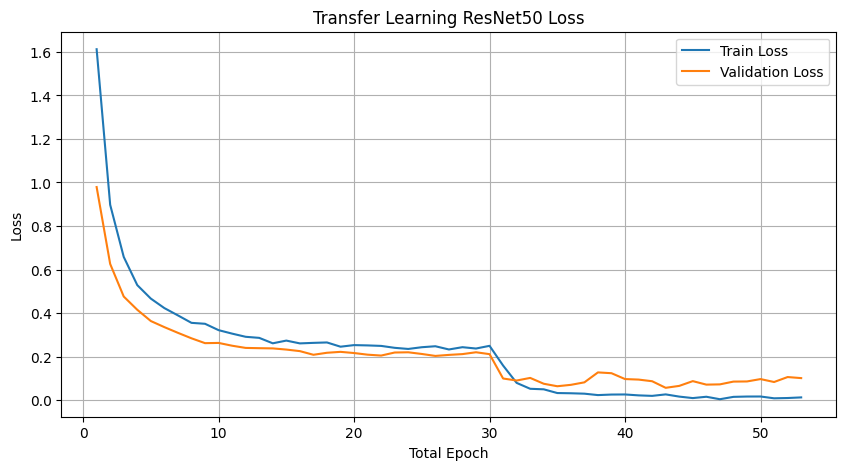

In [53]:
# =========================
# 4단계-16. Loss 그래프 시각화
# =========================

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(transfer_history_df) + 1),
    transfer_history_df["train_loss"],
    label="Train Loss"
)

plt.plot(
    range(1, len(transfer_history_df) + 1),
    transfer_history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Total Epoch")
plt.ylabel("Loss")
plt.title("Transfer Learning ResNet50 Loss")
plt.legend()
plt.grid(True)
plt.show()

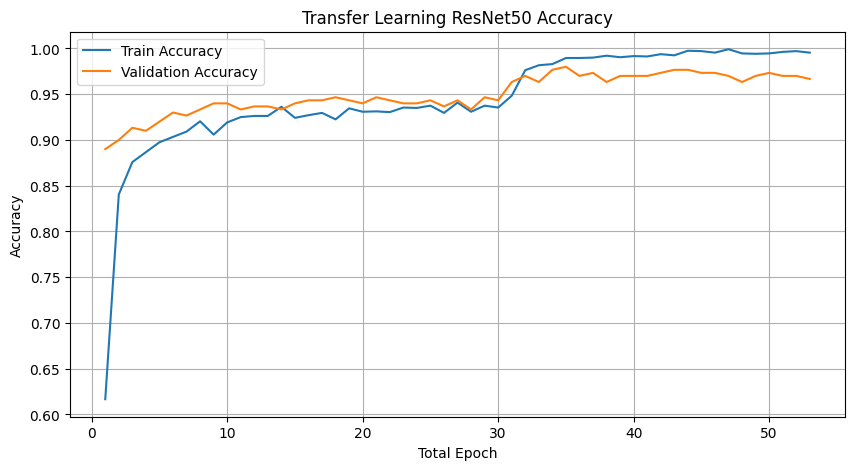

In [54]:
# =========================
# 4단계-17. Accuracy 그래프 시각화
# =========================

plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(transfer_history_df) + 1),
    transfer_history_df["train_acc"],
    label="Train Accuracy"
)

plt.plot(
    range(1, len(transfer_history_df) + 1),
    transfer_history_df["val_acc"],
    label="Validation Accuracy"
)

plt.xlabel("Total Epoch")
plt.ylabel("Accuracy")
plt.title("Transfer Learning ResNet50 Accuracy")
plt.legend()
plt.grid(True)
plt.show()